# DETECCIÓN DE ANOMALÍAS Y TÉCNICAS DE AGRUPAMIENTO

Objetivo 

Mediante este trabajo se pretende que poner en práctica la aplicación de los algoritmos de detección de anomalías u outliers y las técnicas de agrupamiento. El objetivo es detectar anomalías, generar y analizar agrupaciones aplicando algoritmos de aprendizaje máquina, con el fin de elegir el mejor método para el conjunto de datos dado. 

En la presente actividad se va a emplear un dataset que contiene información de un conjunto de datos, que proviene de estudios de cardiotocografía (CTG) y contiene medidas extraídas de las señales de frecuencia cardíaca fetal (FHR) y contracciones uterinas. 

<h3> Acerca del conjunto de datos </h3>  

<h3> Contexto </h3>

Se procesaron automáticamente 2126 cardiotocogramas fetales (CTG) y se midieron las características diagnósticas respectivas. Los CTG también fueron clasificados por tres obstetras expertos y se asignó una etiqueta de clasificación consensuada a cada uno de ellos. La clasificación se realizó tanto con respecto a un patrón morfológico (A, B, C, …) como al estado fetal (N, S, P). Por lo tanto, el conjunto de datos puede usarse tanto para experimentos de 10 clases como de 3 clases.

Después de un análisis se puede decir que, la información del *dataset* es:

INFORMACIÓN GENERAL

* *FileName / SegFile*: Nombre del archivo original y del segmento analizado.

* *Date*: Fecha en la que se realizó el estudio.

* *b / e*: Instante de inicio (b) y de fin (e) del segmento de la señal.

CARACTERÍSTICAS DE LA FRECUENCIA CARDÍACA FETAL (FHR)

* *LBE (Fetal Heart Rate Baseline)*: Es la línea de base de la frecuencia cardíaca fetal en latidos por minuto calculada de forma automática por el software SisPorto (Sistema informático utilizado para procesar los cardiotocogramas).

* *LB (Baseline Estimate)*: Es la estimación de la línea de base realizada por los expertos obstetras en latidos por minuto.

* *AC*: Número de aceleraciones por segundo.

* *FM*: Número de movimientos fetales por segundo.

* *UC*: Número de contracciones uterinas por segundo.

* *DL*: Número de desaceleraciones ligeras por segundo.

* *DS*: Número de desaceleraciones severas por segundo.

* *DP*: Número de desaceleraciones prolongadas por segundo.

* *DR*: Número de desaceleraciones repetitivas por segundo.

MEDIDAS DE VARIABILIDAD

* *ASTV*: Porcentaje de tiempo con variabilidad anormal a corto plazo.

* *MSTV*: Valor medio de la variabilidad a corto plazo.

* *ALTV*: Porcentaje de tiempo con variabilidad anormal a largo plazo.

* *MLTV*: Valor medio de la variabilidad a largo plazo.

ESTADÍSTICAS DEL HISTOGRAMA

Distribución de la Frecuencia Cardíaca Fetal (FHR)

* *Width*: Ancho del histograma de la frecuencia cardíaca.

* *Min / Max*: Valores mínimo y máximo del histograma.

* *Nmax*: Número de picos en el histograma.

* *Nzeros*: Número de ceros en el histograma.

* *Mode / Mean / Median*: Moda, media y mediana de la frecuencia cardíaca.

* *Variance*: Varianza del histograma.

* *Tendency*: Tendencia del histograma (-1: asimetría a la izquierda, 0: simétrico, 1: asimetría a la derecha).

CLASIFICACIÓN MORFOLÓGICA (Patrones de los Obstetras)

Estas columnas representan 10 clases basadas en el patrón visual (son valores binarios 0 o 1):

* *A*: Sueño tranquilo.

* *B*: Sueño REM.

* *C*: Vigilancia tranquila.

* *D*: Vigilancia activa.

* *E*: Patrón de cambio (A o B con oscilaciones).

* *AD*: Patrón acelerativo/desacelerativo (estrés).

* *DE*: Patrón desacelerativo (estrés).

* *LD*: Patrón de desaceleración prolongada.

* *FS*: Patrón plano-sinusoidal (patológico).

* *SUSP*: Patrón sospechoso.

* *CLASS*: Código numérico del patrón morfológico (del 1 al 10, correspondiente a las letras anteriores).

CLASIFICACIÓN DEL ESTADO FETAL

NSP: Esta es la etiqueta de clasificación de 3 clases (Estado fetal):

* *1 (N)*: Normal.

* *2 (S)*: Sospechoso (Suspect).

* *3 (P)*: Patológico.


### IMPORTACIÓN DE LIBRERIAS A UTILIZAR

In [61]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn import svm
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

### CARGA DEL DATASET

In [62]:
# Se carga de dataset 'train.csv y se muestra su contenido'
df = pd.read_csv('CTG.csv')
df

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,Variab10.txt,12/1/1996,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,Fmcs_1.txt,5/3/1996,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,Fmcs_1.txt,5/3/1996,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,5/3/1996,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,5/3/1996,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2124,S8001045.dsp,6/6/1998,CTG2127.txt,1576.0,3049.0,140.0,140.0,1.0,0.0,9.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2125,S8001045.dsp,6/6/1998,CTG2128.txt,2796.0,3415.0,142.0,142.0,1.0,1.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
#El tamaño del dataset: existen 21 columnas con 2000 datos cada una

print(f'El dataset tiene {df.shape[0]} filas (registros) y {df.shape[1]} columnas (variables)')


El dataset tiene 2129 filas (registros) y 40 columnas (variables)


In [64]:
# Se muestran las primeras 5 filas de datos
df.head(5)

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,Variab10.txt,12/1/1996,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,Fmcs_1.txt,5/3/1996,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,Fmcs_1.txt,5/3/1996,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,5/3/1996,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,5/3/1996,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0


In [65]:
#Se muestran las ultimas 5 filas de datos
df.tail(5)

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
2124,S8001045.dsp,6/6/1998,CTG2127.txt,1576.0,3049.0,140.0,140.0,1.0,0.0,9.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2125,S8001045.dsp,6/6/1998,CTG2128.txt,2796.0,3415.0,142.0,142.0,1.0,1.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,564.0,23.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<h3> Acerca del conjunto de datos </h3> 

* Se observa que, las tres ultimas filas del dataset contienen datos faltantes o nulos.


# 1. ANÁLISIS DESCRIPTIVO DE DATOS


## Limpieza de datos

<h3> Datos Nulos (NaN) </h3>


In [66]:
# Por el metodo .info se encontraron 3 filas del dataset con datos nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 40 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   FileName  2126 non-null   object 
 1   Date      2126 non-null   object 
 2   SegFile   2126 non-null   object 
 3   b         2126 non-null   float64
 4   e         2126 non-null   float64
 5   LBE       2126 non-null   float64
 6   LB        2126 non-null   float64
 7   AC        2126 non-null   float64
 8   FM        2127 non-null   float64
 9   UC        2127 non-null   float64
 10  ASTV      2127 non-null   float64
 11  MSTV      2127 non-null   float64
 12  ALTV      2127 non-null   float64
 13  MLTV      2127 non-null   float64
 14  DL        2128 non-null   float64
 15  DS        2128 non-null   float64
 16  DP        2128 non-null   float64
 17  DR        2128 non-null   float64
 18  Width     2126 non-null   float64
 19  Min       2126 non-null   float64
 20  Max       2126 non-null   floa

<h3> Eliminación de datos </h3> 

* Las variables FM, UC, ASTV, MSTV, ALTV, MLTV, DL, DS, DP, DR, apenas contienen algunos datos aislados en sus dos ultimas filas, pero no aportan valor al estudio, por lo que se ha decidido eliminar estas últimas 3 filas del conjunto de datos, para trabajar únicamente con los 2126 registros de datos completos.


In [67]:
# Se eliminan las tres ultimas filas que contienen datos faltantes
df_3del = df.drop(df.index[-3:])

In [68]:
#Se muestran las ultimas 5 filas de datos
df_3del.tail(5)

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
2121,S8001045.dsp,6/6/1998,CTG2124.txt,2059.0,2867.0,140.0,140.0,0.0,0.0,6.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2122,S8001045.dsp,6/6/1998,CTG2125.txt,1576.0,2867.0,140.0,140.0,1.0,0.0,9.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2123,S8001045.dsp,6/6/1998,CTG2126.txt,1576.0,2596.0,140.0,140.0,1.0,0.0,7.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2124,S8001045.dsp,6/6/1998,CTG2127.txt,1576.0,3049.0,140.0,140.0,1.0,0.0,9.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2125,S8001045.dsp,6/6/1998,CTG2128.txt,2796.0,3415.0,142.0,142.0,1.0,1.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [69]:
#El tamaño del dataset: existen 21 columnas con 2000 datos cada una

print(f'El dataset tiene {df_3del.shape[0]} filas (registros) y {df_3del.shape[1]} columnas (variables)')


El dataset tiene 2126 filas (registros) y 40 columnas (variables)



* Se han eliminado las tres ultimas filas con datos faltantes, no contienen información que aporte valor al estudio.


In [70]:
# Se calcula cuantos valores NaN exiten en el nuevo dataset
df_3del.isna().sum()

FileName    0
Date        0
SegFile     0
b           0
e           0
LBE         0
LB          0
AC          0
FM          0
UC          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
DL          0
DS          0
DP          0
DR          0
Width       0
Min         0
Max         0
Nmax        0
Nzeros      0
Mode        0
Mean        0
Median      0
Variance    0
Tendency    0
A           0
B           0
C           0
D           0
E           0
AD          0
DE          0
LD          0
FS          0
SUSP        0
CLASS       0
NSP         0
dtype: int64

In [71]:
# Por el metodo .info no se encontraron datos nulos en el dataset
df_3del.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 40 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   FileName  2126 non-null   object 
 1   Date      2126 non-null   object 
 2   SegFile   2126 non-null   object 
 3   b         2126 non-null   float64
 4   e         2126 non-null   float64
 5   LBE       2126 non-null   float64
 6   LB        2126 non-null   float64
 7   AC        2126 non-null   float64
 8   FM        2126 non-null   float64
 9   UC        2126 non-null   float64
 10  ASTV      2126 non-null   float64
 11  MSTV      2126 non-null   float64
 12  ALTV      2126 non-null   float64
 13  MLTV      2126 non-null   float64
 14  DL        2126 non-null   float64
 15  DS        2126 non-null   float64
 16  DP        2126 non-null   float64
 17  DR        2126 non-null   float64
 18  Width     2126 non-null   float64
 19  Min       2126 non-null   float64
 20  Max       2126 non-null   floa


* No se encontraron datos NaN en el nuevo dataset.


## Variables

<h3> Tipos de variables </h3> 

In [72]:
# Variables categóricas
lst_catvar = list(df_3del.select_dtypes(include='object'))
lst_catvar = lst_catvar + ['CLASS'] + ['NSP'] + ['Tendency']
print(f'Variables categóricas\n{lst_catvar}')
# Variables categóricas dicotómicas 
lst_dicvar = [dic for dic in df_3del.columns if df_3del[dic].nunique(dropna=True) == 2 and dic != 'DS']
#lst_dicvar = lst_dicvar
print(f'Variables categóricas dicotómicas\n{lst_dicvar}')
# Variables numéricas discretas
lst_disvar = list(df_3del.select_dtypes(include='int'))
lst_disvar = lst_disvar + ['AC']  + ['FM'] + ['UC'] + ['DL'] + ['DP'] + ['Nmax'] + ['Nzeros'] + ['b'] + ['e'] + ['DR'] + ['DS']
print(f'Variables numéricas discretas\n{lst_disvar}')
# Variables numéricas continuas
lst_contvar = list( set(df_3del.columns) - set(lst_dicvar) - set(lst_disvar) - set(lst_catvar))
print(f'Variables numéricas continuas\n{lst_contvar}')


Variables categóricas
['FileName', 'Date', 'SegFile', 'CLASS', 'NSP', 'Tendency']
Variables categóricas dicotómicas
['A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP']
Variables numéricas discretas
['AC', 'FM', 'UC', 'DL', 'DP', 'Nmax', 'Nzeros', 'b', 'e', 'DR', 'DS']
Variables numéricas continuas
['Width', 'Mean', 'MLTV', 'MSTV', 'LB', 'Max', 'LBE', 'Min', 'ALTV', 'Variance', 'Median', 'ASTV', 'Mode']


In [73]:
# Variables categóricas dicotómicas 
print('Variables categóricas dicotómicas\n')
for col in df_3del[lst_dicvar]:
  lst_unique = df_3del[col].unique()
  if len(lst_unique)<3:
    print(f'{col}: {lst_unique}')
  else:  
    print(f'La variable {col} tiene {len(lst_unique)} valores distintos')

Variables categóricas dicotómicas

A: [0. 1.]
B: [0. 1.]
C: [0. 1.]
D: [0. 1.]
E: [0. 1.]
AD: [0. 1.]
DE: [0. 1.]
LD: [0. 1.]
FS: [1. 0.]
SUSP: [0. 1.]


<h3> Variables Categóricas </h3> 

Variables Categóricas

Se ha identificado las variables categóricas que representan etiquetas o grupos, aunque en el dataset algunas de ellas han sido convertidas a números, su significado es cualitativo, estas son:

* CLASS: Código de la clasificación morfológica (del 1 al 10, donde 1=A, 2=B, etc.), podria ser considerada con variable objetivo para un caso de clasificación de 10 clases.

* NSP: Estado fetal (1 = Normal, 2 = Sospechoso, 3 = Patológico), podria ser considerada con variable objetivo para un caso de clasificación de 3 clases.

* Tendency: Dirección del histograma de la FHR (-1 = Asimétrico izquierda, 0 = Simétrico, 1 = Asimétrico derecha).

* FileName, Date, SegFile: Metadatos identificadores (textos y fechas).

Variables Categóricas Dicotómicas

Se han identificado las variables  binarias que solo pueden tomar dos valores (0 y 1), indican ausencia o presencia de una característica y son:

* Patrones Morfológicos: A, B, C, D, E, AD, DE, LD, FS, SUSP.


In [74]:
# Variables numéricas discretas
print('Variables numéricas discretas\n')
for col in df_3del[lst_disvar]:
  lst_unique = df_3del[col].unique()
  if len(lst_unique)<1:
    print(f'{col}: {lst_unique}')
  else:
    print(f'La variable {col} tiene {len(lst_unique)} valores distintos')

Variables numéricas discretas

La variable AC tiene 22 valores distintos
La variable FM tiene 96 valores distintos
La variable UC tiene 19 valores distintos
La variable DL tiene 15 valores distintos
La variable DP tiene 5 valores distintos
La variable Nmax tiene 18 valores distintos
La variable Nzeros tiene 9 valores distintos
La variable b tiene 979 valores distintos
La variable e tiene 1064 valores distintos
La variable DR tiene 1 valores distintos
La variable DS tiene 2 valores distintos


In [75]:
# Variables numéricas continuas
print('Variables numéricas continuas\n')
for col in df_3del[lst_contvar]:
  lst_unique = df_3del[col].unique()
  if len(lst_unique)<1:
    print(f'{col}: {lst_unique}')
  else:
    print(f'La variable {col} tiene {len(lst_unique)} valores distintos')

Variables numéricas continuas

La variable Width tiene 154 valores distintos
La variable Mean tiene 103 valores distintos
La variable MLTV tiene 249 valores distintos
La variable MSTV tiene 57 valores distintos
La variable LB tiene 48 valores distintos
La variable Max tiene 86 valores distintos
La variable LBE tiene 48 valores distintos
La variable Min tiene 109 valores distintos
La variable ALTV tiene 87 valores distintos
La variable Variance tiene 133 valores distintos
La variable Median tiene 95 valores distintos
La variable ASTV tiene 75 valores distintos
La variable Mode tiene 88 valores distintos


<h3> Variables Numéricas </h3> 

Variables Numéricas Discretas

Se han identificado las variables numéricas discretas, sus valores representan conteos enteros o índices específicos y no admiten valores intermedios en su medición original, estas son:

* Eventos de conteo: AC (Aceleraciones), FM (Movimientos fetales), UC (Contracciones), DL (Desaceleraciones ligeras), DP (Desaceleraciones prolongadas), DS (Desaceleraciones severas), DR (Desaceleraciones repetitivas).

* Histograma: Nmax (Número de picos), Nzeros (Número de ceros).

* Límites: b y e (Índices de inicio y fin del segmento).

Variables Numéricas Continuas

Se ha identificado las variables numéricas continuas, pueden tomar cualquier valor numérico y son:

* Frecuencia Cardíaca: LBE y LB (Línea de base en lpm), Mean (Media), Median (Mediana), Mode (Moda).

* Variabilidad: ASTV y ALTV: Porcentajes de variabilidad anormal (se presentan como enteros pero representan una proporción continua).

* MSTV y MLTV: Valores medios de variabilidad (presentan decimales).

* Distribución: Width (Ancho del histograma), Min (Mínimo), Max (Máximo), Variance (Varianza).


## Datos faltantes

In [76]:
# Se analiza las columnas que tienen valores cero en sus datos, se excluyen las  variables categóricas dicotómicas

cols_zeros = [c for c in df_3del.columns if c not in ['DS', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'DR']]
(df_3del[cols_zeros] == 0).sum(axis=0)


FileName       0
Date           0
SegFile        0
b            314
e              0
LBE            0
LB             0
AC           891
FM          1311
UC           332
ASTV           0
MSTV           0
ALTV        1240
MLTV         137
DL          1231
DP          1948
Width          0
Min            0
Max            0
Nmax         107
Nzeros      1624
Mode           0
Mean           0
Median         0
Variance     187
Tendency    1115
CLASS          0
NSP            0
dtype: int64

<h3> Análisis de datos faltantes </h3> 

Algunas variables del dataset poseen datos con valor de cero, dependiendo de la variable esto puede tener un significado u otro desdee el punto médico, se realiza un análisis para cada una de ellas, cabe mencionar que se ha dejado fuera a las variables categóricas dicotómicas por la naturaleza de sus datos.

Índice o límite del segmento

* b (límite del segmento) = 0: Puede significar que el análisis se realizó desde el momento cero (inicio) del segmento.

Eventos de Bienestar (AC, FM)

* AC (Aceleraciones) = 0: Puede significar que el corazón del bebé no aumentó su ritmo durante ese periodo. Si el bebé está durmiendo (sueño tranquilo), es normal. Sin embargo, si no hay aceleraciones durante mucho tiempo incluso cuando el bebé se mueve, puede indicar que el bebé no tiene suficientes reservas de oxígeno.

* FM (Movimientos Fetales) = 0: Significa que el bebé estuvo quieto durante el registro. Al igual que las aceleraciones, esto es normal durante los ciclos de sueño del feto (que duran unos 20-40 minutos).

Actividad Uterina (UC)

* UC (Contracciones) = 0: Significa que la madre no tuvo contracciones durante el monitoreo. Esto es lo esperado si la paciente no ha entrado en labor de parto o si se trata de un control de rutina.

Medidas de Variabilidad (ASTV, MSTV, ALTV, MLTV)

* ASTV y ALTV (Porcentaje de tiempo anormal) = 0: Significa que no se detectó una variabilidad fuera de los rangos normales. Es decir, el ritmo cardíaco se mantuvo "sano" todo el tiempo.

* MSTV y MLTV (Valor medio de variabilidad) = 0: Significa que el corazón late como un metrónomo exacto, sin ninguna fluctuación (línea plana o "silente"). En medicina fetal, esto es un signo de alarma grave, ya que un corazón sano siempre tiene pequeñas variaciones latido a latido.

Eventos de Estrés o Alerta (DL, DS, DP, DR)

* DL (Desaceleraciones ligeras) = 0: No hubo caídas leves en el ritmo cardíaco.

* DS (Desaceleraciones severas) = 0: No hubo caídas bruscas y peligrosas.

* DP (Desaceleraciones prolongadas) = 0: No hubo caídas que duraran más de 2 minutos.

* DR (Desaceleraciones repetitivas) = 0: No hubo un patrón cíclico de caídas.

Un cero en estas variables suele indicar un feto que no está bajo estrés mecánico o falta de oxígeno por compresiones del cordón.

CONCLUSIÓN

Luego de este análisis realizado con ayuda de la parte médica, se puede decir que no existen datos faltantes en el dataset, como se describió en los  enunciados anteriores, un cero presente en estas variables tiene distintos significados desde el punto de vista médico.

BIBLIOGRAFÍA

Ayres-de-Campos, D., Spong, C. Y., & Chandraharan, E. (2015). FIGO consensus guidelines on intrapartum fetal monitoring: Cardiotocography. International Journal of Gynecology & Obstetrics, 131(1), 13-24.

## Valores duplicados

In [77]:
df_3del.duplicated().sum()

np.int64(0)

* No se encontraron datos duplicados en el dataset.

## Variables numéricas

<h4> Matriz de Correlación</h4>

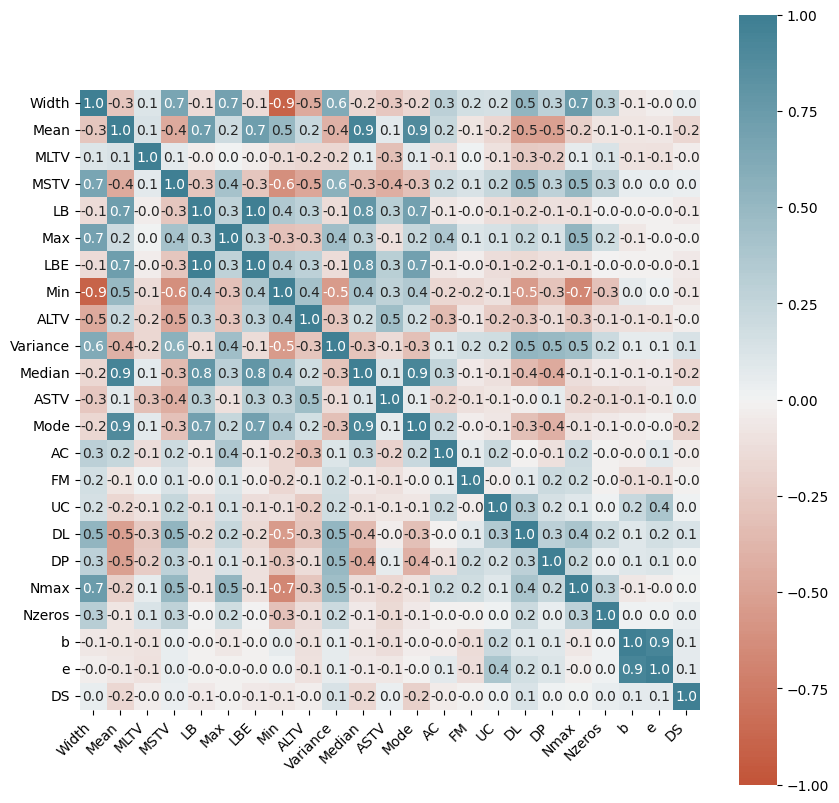

In [78]:
# Matriz decorrelaciones numericas original, se excluye la variable DR por no contener datos

lst_disvar.remove('DR')
df_num = df_3del[lst_contvar+lst_disvar]

corr= df_num.corr()
plt.figure(figsize=(10, 10))
ax = sb.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sb.diverging_palette(20, 220, n=200),
    square=True,
    annot = True, fmt=".1f"
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
);

<h3> Correlación Numérica </h3> 

RELACIONES CLÍNICAS 

* Las variables *LBE (Fetal Heart Rate Baseline) y LB (Baseline Estimate)*, poseen una $correlación = 1$, esto sugiere que  poseen la misma información, es decir tanton el el software SisPorto (el sistema informático utilizado para procesar los cardiotocogramas), como la estimación de la línea de base realizada por los expertos obstetras,es  la misma.
  
* Las variables *Mean, Median y Mode*, poseen una $correlación = 0.9$, esto sugiere que la distribución de los latidos del corazón de los fetos es bastante simetríca con ausencia de sesgo significativo, puede significar también que, estas medidas poseen valores muy cercanos entre si aportan información muy parecida.

* Las variables *LBE (Fetal Heart Rate Baseline), LB (Baseline Estimate) y Median, Mode, Mean*, poseen una $correlacion = 0.8, 0,7 y 0,7$ respectivamente, sugiere que, la línea de base de la frecuencia cardíaca fetal en latidos por minuto es sobre la cual se calcularon los valores promedios con los datos de estas variables.

HISTOGRAMA

* Las variables *Width (Ancho del histograma de la FHR) y Min (Valor mínimo del histograma de la frecuencia cardíaca)*, poseen una fuerte $correlación negativa = -0.9$, esto puede significar que el ancho del histograma está determinado principalmente por qué tan bajo cae la frecuencia cardíaca (las desaceleraciones), más que por qué tan alto sube.
  
* Las variables *Width (Ancho del histograma de la FHR) y NMax (Número de picos en el histograma)*, poseen una $correlación = 0.7$, esto significa que cuanto más amplio es el rango de pulsaciones, más "picos" o modas locales aparecen en el gráfico, desde el punto clínico, esto tiene sentido, pues un feto activo pasa por diferentes estados de ritmo cardiaco.

* Las variables *NMax (Número de picos en el histograma) y Min (Valor mínimo del histograma)*, poseen una $correlación negativa = -0.7$, esto significa que a menor valor de Min (frecuencia cardíaca más baja detectada), mayor tiende a ser el valor de Nmax (más picos en el histograma),es decir que son inversamente proporcionales entre si.

* La variable *Width (Ancho del histograma de la FHR) y MSTV (Valor medio de la variabilidad a corto plazo), Variance (Varianza del histograma)* poseen una $correlacion = 0,7 y 0,6$ respectivamente, siginifica una relación importante entre el ancho del histograma y la varianza, que están ligados a la variabilidad a corto plazo. Si un feto tiene mucha variabilidad en su FHR, el histograma naturalmente se ensancha.

* Las variables *MSTV (Valor medio de la variabilidad a corto plazo) y Min (Valor mínimo del histograma)* , poseen una $correlación negativa = -0.6$, siginifica que una variabilidad alta a corto plazo suele estar asociada a la presencia de caídas en el ritmo (desaceleraciones), lo que baja el valor mínimo registrado.

DATOS AISLADOS

* Las variables *b y e (Instante de inicio (b) y de fin (e) del segmento de la señal)*, poseen una $correlación = 0.9$, solo entre ellas, lo que sugiere que no aportan ninguna relación especial con el resto de variables.

* Las variables *FM (Movimientos Fetales) y UC (Contracciones)*, muestran $correlaciones < 0.9$ muy bajas en relación al resto de variables, es decir que estas variables aportan información independiente que no puede ser explicada por la frecuencia cardíaca.


<h3> Datos Estadísticos </h3>

In [79]:
# Resumen estadístico de las variables numéricas

df_3del[lst_contvar+lst_disvar].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Width,2126.0,70.445908,38.955693,3.0,37.0,67.5,100.00,180.0
Mean,2126.0,134.610536,15.593596,73.0,125.0,136.0,145.00,182.0
MLTV,2126.0,8.187629,5.628247,0.0,4.6,7.4,10.80,50.7
MSTV,2126.0,1.332785,0.883241,0.2,0.7,1.2,1.70,7.0
LB,2126.0,133.303857,9.840844,106.0,126.0,133.0,140.00,160.0
Max,2126.0,164.025400,17.944183,122.0,152.0,162.0,174.00,238.0
LBE,2126.0,133.303857,9.840844,106.0,126.0,133.0,140.00,160.0
Min,2126.0,93.579492,29.560212,50.0,67.0,93.0,120.00,159.0
ALTV,2126.0,9.846660,18.396880,0.0,0.0,0.0,11.00,91.0
Variance,2126.0,18.808090,28.977636,0.0,2.0,7.0,24.00,269.0


* Las variables *LBE (Fetal Heart Rate Baseline) y LB (Baseline Estimate)*, presentan  datos estadisticos iguales, lo que confirma que poseen la misma información.
* Las variables *LBE (Fetal Heart Rate Baseline), LB (Baseline Estimate) y Median, Mode, Mean*, presentan una distribucion de datos muy similar, poseen una $media = 133.3 / 133.3, 134.61, 138.09 y 137.45$ respectivamente, esto significa que la gran mayoría de los registros corresponden a fetos con una frecuencia cardíaca normal y estable. El hecho de que la Moda y la Mediana sean casi iguales (139 lpm) sugiere que la distribución principal es unimodal y muy simétrica en el centro.
* Las variables *Nzeros (Número de ceros en el histograma), DL (Número de desaceleraciones ligeras por segundo), DP (Número de desaceleraciones prolongadas por segundo), FM (Número de movimientos fetales por segundo) y ALTV (Porcentaje de tiempo con variabilidad anormal a largo plazo)*, poseen una concentracion de sus datos en los ultimos cuartiles, por consecuencia sus primeros cuartiles estan vacios y como estas variables representan valores anormales en la FHR y la mayoria de sus datos son cero, esto sugiere que basado en la distribución de estas variables y el análisis de los cuartiles reflejan que, la mayoria de los pacientes del dataset son fetos con FHR normal y que el conjunto de datos está fuertemente sesgado hacia estos fetos con estado de salud normal.

<h3> Eliminación de datos </h3>

In [80]:
# Se realiza una copia del dataset para modificaciones
df_data = df_3del.copy()

In [81]:
# Se eliminan las variables no necesarias para el análisis de anomalias y clusters.
df_data.drop(['FileName', 'Date', 'SegFile', 'LB', 'DR', 'b', 'e'], axis=1, inplace=True)

In [82]:
df_data.head(10)

,LBE,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,120.0,0.0,0.0,0.0,73.0,0.5,43.0,2.4,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,132.0,4.0,0.0,4.0,17.0,2.1,0.0,10.4,2.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,133.0,2.0,0.0,5.0,16.0,2.1,0.0,13.4,2.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,134.0,2.0,0.0,6.0,16.0,2.4,0.0,23.0,2.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,132.0,4.0,0.0,5.0,16.0,2.4,0.0,19.9,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
5,134.0,1.0,0.0,10.0,26.0,5.9,0.0,0.0,9.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8.0,3.0
6,134.0,1.0,0.0,9.0,29.0,6.3,0.0,0.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8.0,3.0
7,122.0,0.0,0.0,0.0,83.0,0.5,6.0,15.6,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,3.0
8,122.0,0.0,0.0,1.0,84.0,0.5,5.0,13.6,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,3.0
9,122.0,0.0,0.0,3.0,86.0,0.3,6.0,10.6,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,3.0


Se han eliminado estas variables por no contener informacion que aporte valor al estudio de anomalías y a la agrupacion por clusters, estas son:

*  FileName / SegFile: Nombre del archivo original y del segmento analizado.
*  Date: Fecha en la que se realizó el estudio.
*  b / e: Instante de inicio (b) y de fin (e) del segmento de la señal FHR analizada.
*  LB (Baseline Estimate): Es la estimación de la línea de base realizada por los expertos obstetras en latidos por minuto, se ha eliminado por que contiene la misma informacion que su variable gemela LBE.
*  DR: Número de desaceleraciones repetitivas por segundo, esta variable no contiene datos, todos sus registros son cero.

## Tipos de Variables

<h3> Análisis y la creación de gráficos de frecuencia </h3> 

In [83]:
# Variables categóricas
lst_catvar = list(df_data.select_dtypes(include='object'))
lst_catvar = lst_catvar + ['CLASS'] + ['NSP'] + ['Tendency']
print(f'Variables categóricas\n{lst_catvar}')
# Variables categóricas dicotómicas 
lst_dicvar = [dic for dic in df_data.columns if df_data[dic].nunique(dropna=True) == 2 and dic != 'DS']
lst_dicvar = lst_dicvar
print(f'Variables categóricas dicotómicas\n{lst_dicvar}')
# Variables numéricas discretas
lst_disvar = list(df_data.select_dtypes(include='int'))
lst_disvar = lst_disvar + ['AC']  + ['FM'] + ['UC'] + ['DL'] + ['DP'] + ['Nmax'] + ['Nzeros'] + ['DS']
print(f'Variables numéricas discretas\n{lst_disvar}')
# Variables numéricas continuas
lst_contvar = list( set(df_data.columns) - set(lst_dicvar) - set(lst_disvar) - set(lst_catvar))
print(f'Variables numéricas continuas\n{lst_contvar}')


Variables categóricas
['CLASS', 'NSP', 'Tendency']
Variables categóricas dicotómicas
['A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP']
Variables numéricas discretas
['AC', 'FM', 'UC', 'DL', 'DP', 'Nmax', 'Nzeros', 'DS']
Variables numéricas continuas
['Width', 'Mean', 'MSTV', 'Max', 'LBE', 'Min', 'ALTV', 'Mode', 'Variance', 'Median', 'ASTV', 'MLTV']


## Variables Categóricas

## Variable Target NSP

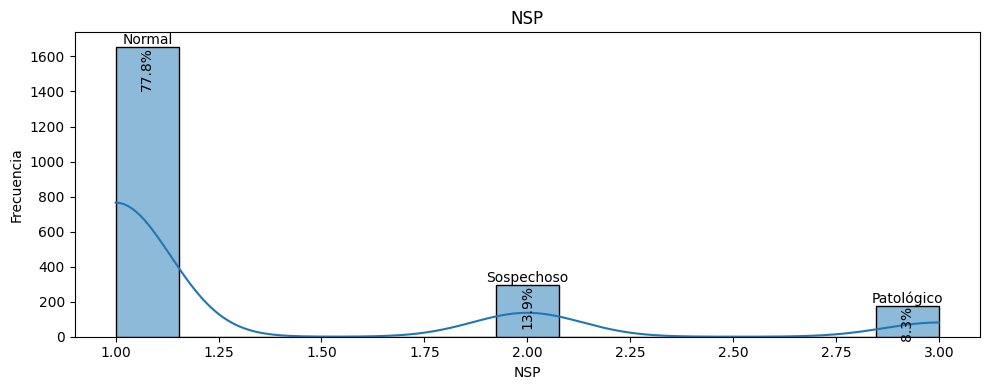

In [84]:

# Diccionario de etiquetas
class_labels_1 = {1: 'Normal', 2: 'Sospechoso', 3: 'Patológico'}

plt.figure(figsize=(10, 4))

# Crear el histograma
ax = sb.histplot(df_data['NSP'], kde=True)

# Agregar porcentajes sobre cada barra con rotación
total = len(df_data[lst_catvar])
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Solo añadir el porcentaje si la altura es mayor que cero
        # Calcular el porcentaje
        percentage = f'{100 * height / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + height
        value = int(round(x))  # redondear al valor de clase
        label = class_labels_1.get(value, '')
        # Añadir el porcentaje como anotación con rotación
        ax.annotate(percentage, (x, y), ha='center', va='top', rotation=90)
        ax.text(x, y, label, ha='center', va='bottom', fontsize=10)

# Ajustes del gráfico
plt.title('NSP')
plt.xlabel('NSP')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

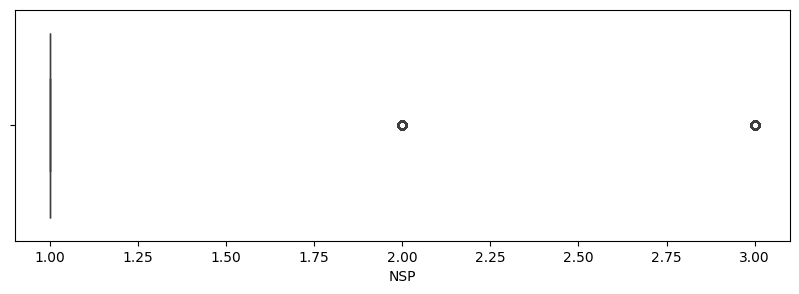

In [85]:
plt.figure(figsize=(10, 3))
sb.boxplot(df_data['NSP'], orient='h')
plt.show()

In [86]:
# El dataset se encuentra balaceado en su variable de salida price_range

df_data['NSP'].value_counts() 


NSP
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64

<h3> Acerca del conjunto de datos </h3> 

* El dataset se encuentra desbalaceado en su variable de salida NSP.

## Variable Target CLASS

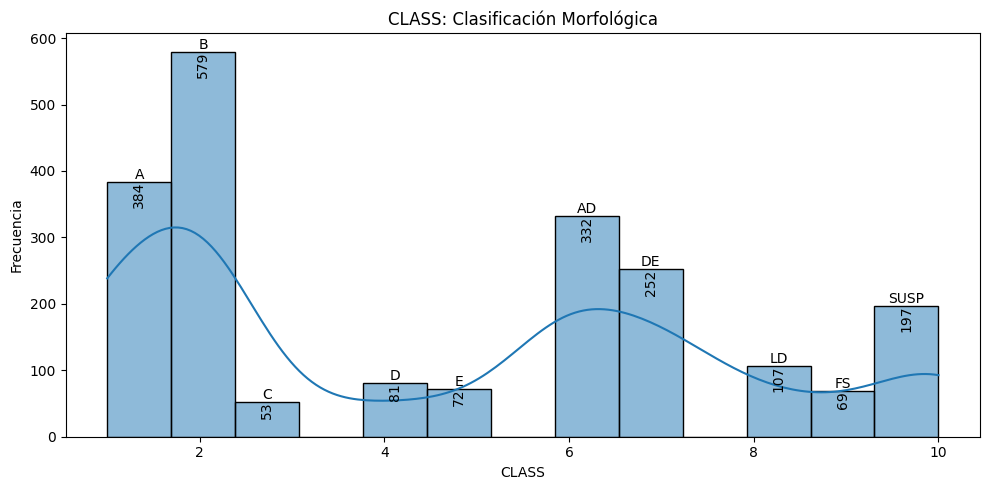

In [87]:

# Diccionario de etiquetas
class_labels_2 = {1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E', 6: 'AD', 7: 'DE', 8: 'LD', 9: 'FS', 10: 'SUSP'} 

plt.figure(figsize=(10, 5))

# Crear el histograma
ax = sb.histplot(df_data['CLASS'], kde=True)

# Agregar porcentajes sobre cada barra con rotación
# total = len(df_data[lst_catvar])
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Solo añadir el porcentaje si la altura es mayor que cero
        # Calcular el porcentaje
        # percentage = f'{100 * height / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + height
        value = int(round(x))  # redondear al valor de clase
        label = class_labels_2.get(value, '')
        # Añadir el porcentaje como anotación con rotación
        ax.annotate(height, (x, y), ha='center', va='top', rotation=90)
        ax.text(x, y, label, ha='center', va='bottom', fontsize=10)

# Ajustes del gráfico
plt.title('CLASS: Clasificación Morfológica')
plt.xlabel('CLASS')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

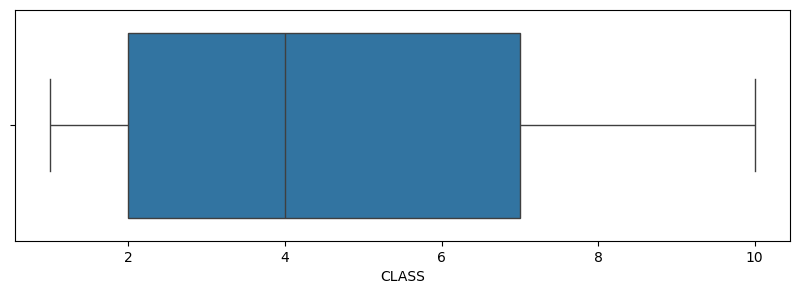

In [88]:
plt.figure(figsize=(10, 3))
sb.boxplot(df_data['CLASS'], orient='h')
plt.show()

In [89]:
# El dataset se encuentra balaceado en su variable de salida price_range

df_data['CLASS'].value_counts() 


CLASS
2.0     579
1.0     384
6.0     332
7.0     252
10.0    197
8.0     107
4.0      81
5.0      72
9.0      69
3.0      53
Name: count, dtype: int64

<h3> Acerca del conjunto de datos </h3> 

* El dataset se encuentra desbalaceado en su segunda variable de salida CLASS.

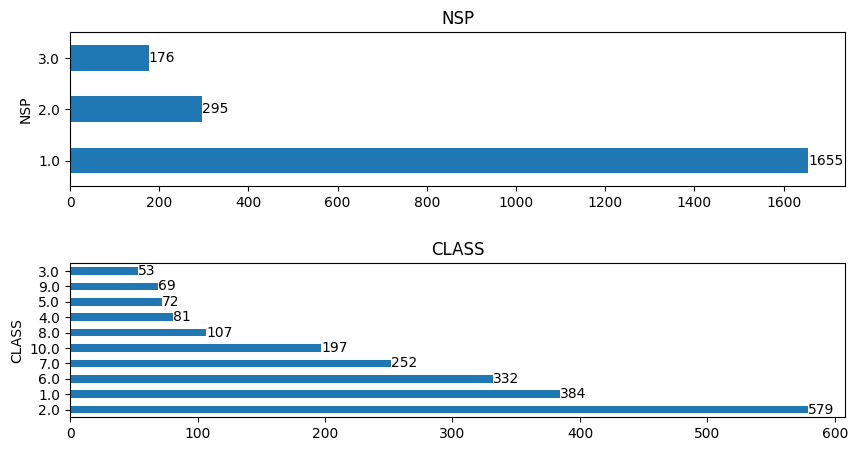

In [90]:

lst_num_1 = ['NSP', 'CLASS']

fig,axes = plt.subplots(nrows=2, ncols=1, figsize=(10,5))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

for col, ax in zip(df_data[lst_num_1], axes.ravel()):
    df_3del[col].value_counts().plot.barh(ax=ax)
    ax.set_title(col)
    ax.bar_label(ax.containers[0])
plt.show()





## Variable Tendency

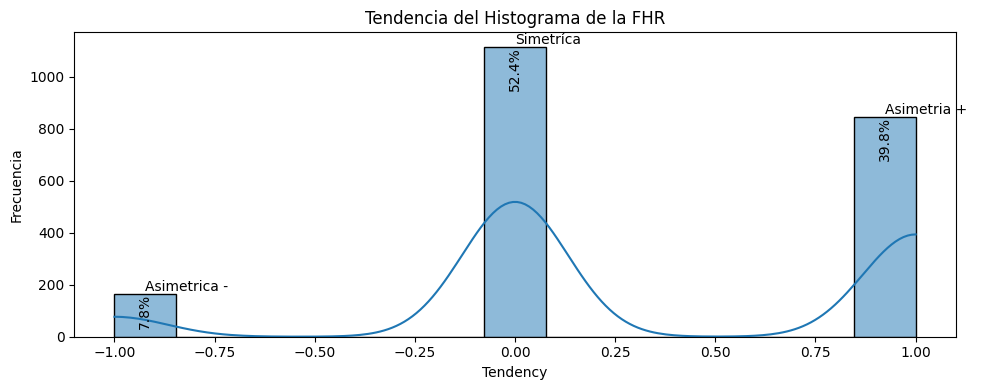

In [91]:

# Diccionario de etiquetas
class_labels_3 = {-1: 'Asimetrica - ', 0: 'Simetríca', 1: 'Asimetria + '}

plt.figure(figsize=(10, 4))

# Crear el histograma
ax = sb.histplot(df_data['Tendency'], kde=True)

# Agregar porcentajes sobre cada barra con rotación
total = len(df_data[lst_catvar])
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Solo añadir el porcentaje si la altura es mayor que cero
        # Calcular el porcentaje
        percentage = f'{100 * height / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + height
        value = int(round(x))  # redondear al valor de clase
        label = class_labels_3.get(value, '')
        # Añadir el porcentaje como anotación con rotación
        ax.annotate(percentage, (x, y), ha='center', va='top', rotation=90)
        ax.text(x, y, label, ha='left', va='bottom', fontsize=10)

# Ajustes del gráfico
plt.title('Tendencia del Histograma de la FHR')
plt.xlabel('Tendency')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

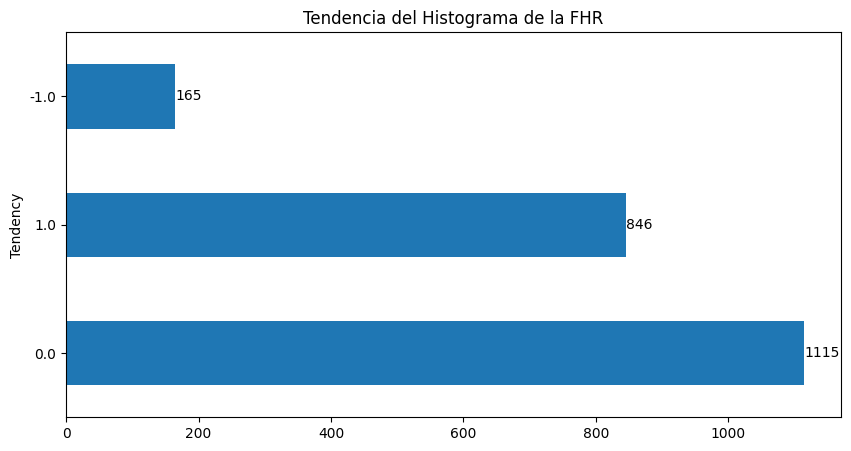

In [92]:

# Crear una sola figura y eje
fig, ax = plt.subplots(figsize=(10, 5))

# Graficar
df_data['Tendency'].value_counts().plot.barh(ax=ax)

# Títulos y etiquetas
ax.set_title(col)
ax.bar_label(ax.containers[0])

#plt.tight_layout()
plt.title('Tendencia del Histograma de la FHR')
plt.show()

## Variable Categóricas Dicotómicas

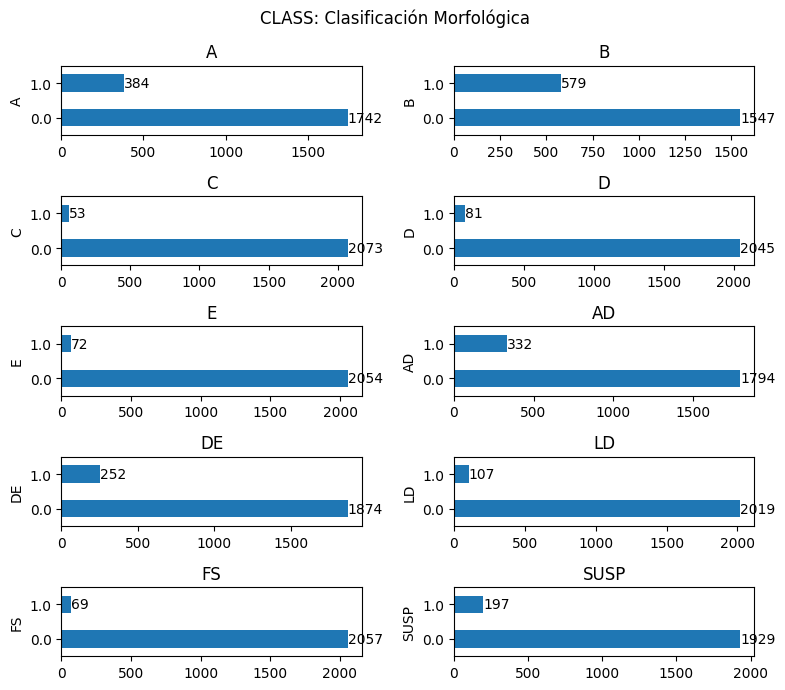

In [93]:
# Se grafican 4 variables categóricas dicotómicas

lst_num_2 = ['A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP']

fig,axes = plt.subplots(nrows=5, ncols=2, figsize=(8,7))

plt.subplots_adjust(
    wspace=1,
    hspace=1
)

for col, ax in zip(df_data[lst_num_2], axes.ravel()):
    df_data[col].value_counts().plot.barh(ax=ax)
    ax.set_title(col)
    ax.bar_label(ax.containers[0])
    
fig.suptitle('CLASS: Clasificación Morfológica', fontsize=12)
plt.tight_layout()
plt.show()


## Variables Numéricas

<h3> Distribución de las variables numéricas </h3> 


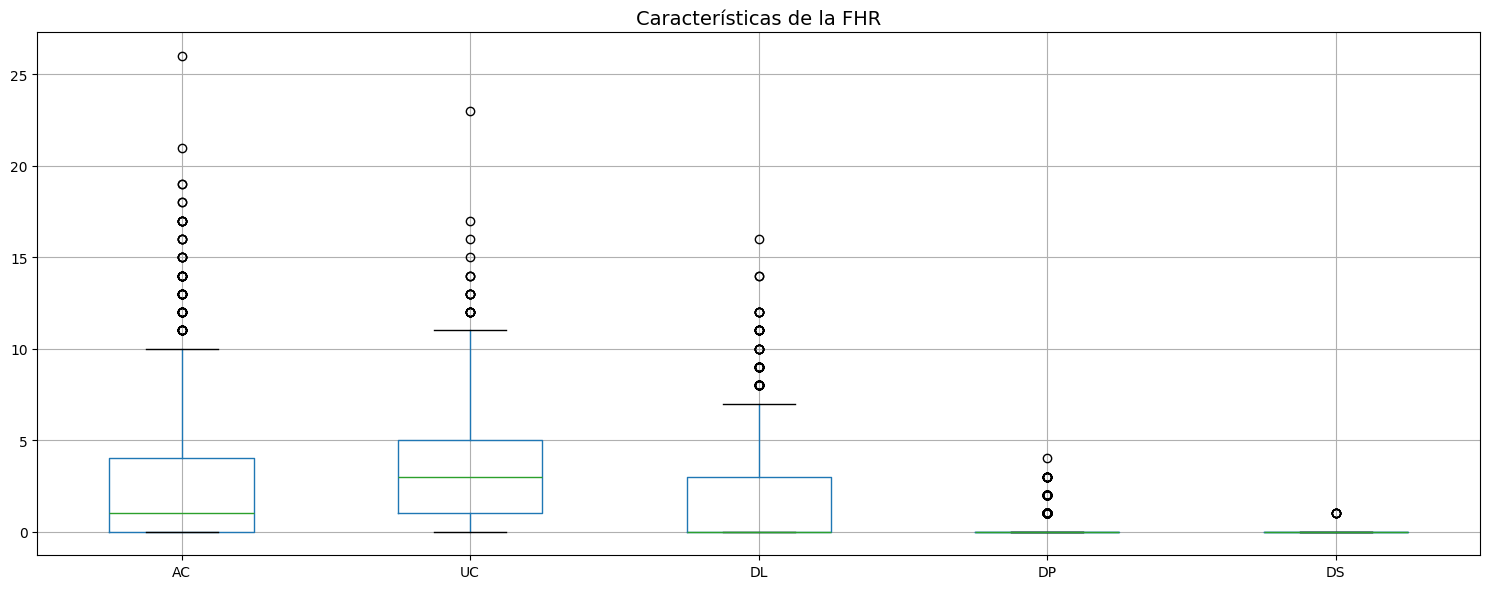

In [94]:
lst_num_3 = ['AC', 'UC', 'DL', 'DP','DS']

# Se grafican los diagramas de caja de cada una de las variables numéricas

boxplot = df_data[lst_num_3].boxplot(figsize=(15,6))

plt.title('Características de la FHR', fontsize=14)
plt.tight_layout()
plt.show()

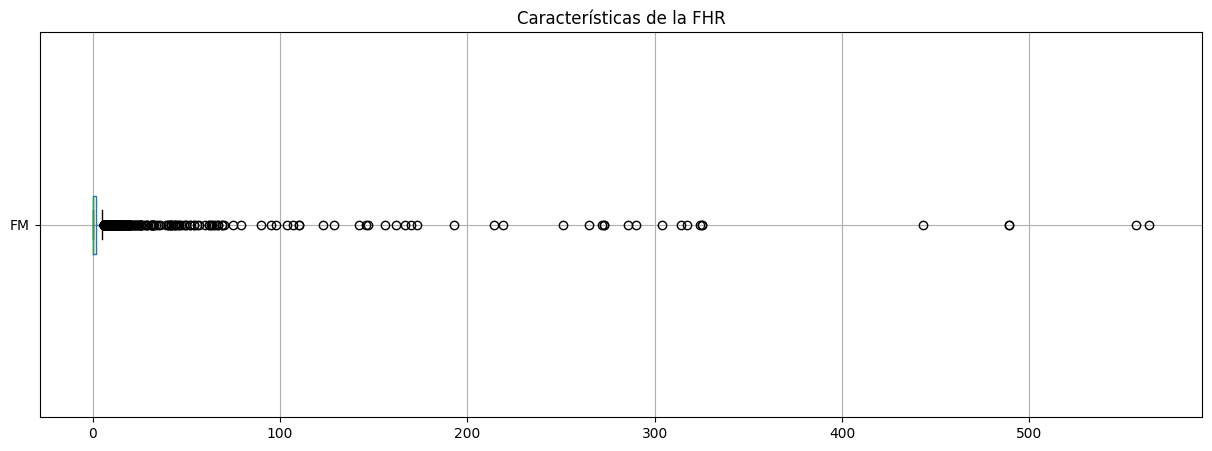

In [95]:
lst_num_4 = ['FM']

# Se grafican los diagramas de caja de cada una de las variables numéricas

boxplot = df_data[lst_num_4].boxplot(figsize=(15,5), vert=False)

plt.title('Características de la FHR', fontsize=12)
plt.show()

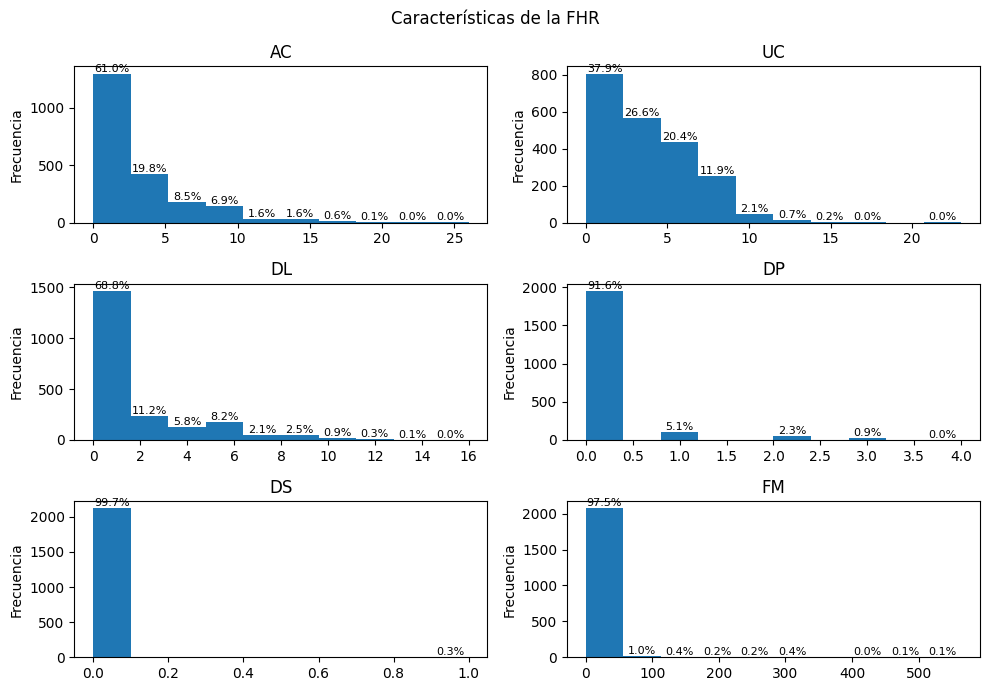

In [96]:
lst_num_5 = lst_num_3 + ['FM'] 
bins = 10

fig, axes = plt.subplots(3, 2, figsize=(10, 7))
axes = axes.flatten()

for ax, col in zip(axes, lst_num_5):
    data = df_data[col].dropna()

    counts, bins_edges, patches = ax.hist(data, bins=bins)

    total = len(data)

    # Porcentajes sobre cada barra
    for count, patch in zip(counts, patches):
        if count > 0:
            percentage = count / total * 100
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                count,
                f'{percentage:.1f}%',
                ha='center',
                va='bottom',
                fontsize=8
            )

    ax.set_title(col)
    ax.set_ylabel('Frecuencia')

plt.gcf().suptitle('Características de la FHR', fontsize=12)
plt.tight_layout()
plt.show()


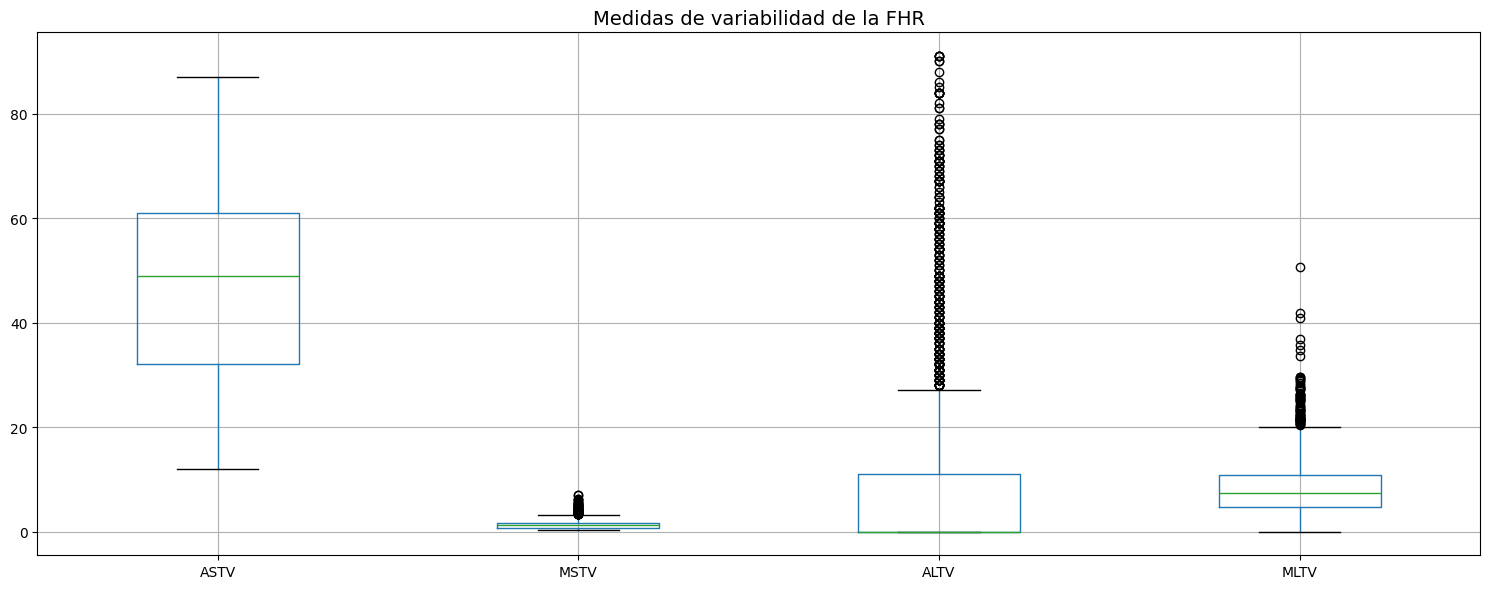

In [97]:
lst_num_6 = ['ASTV', 'MSTV', 'ALTV', 'MLTV']

# Se grafican los diagramas de caja de cada una de las variables numéricas

boxplot = df_data[lst_num_6].boxplot(figsize=(15,6))
plt.title('Medidas de variabilidad de la FHR', fontsize=14)
plt.tight_layout()
plt.show()

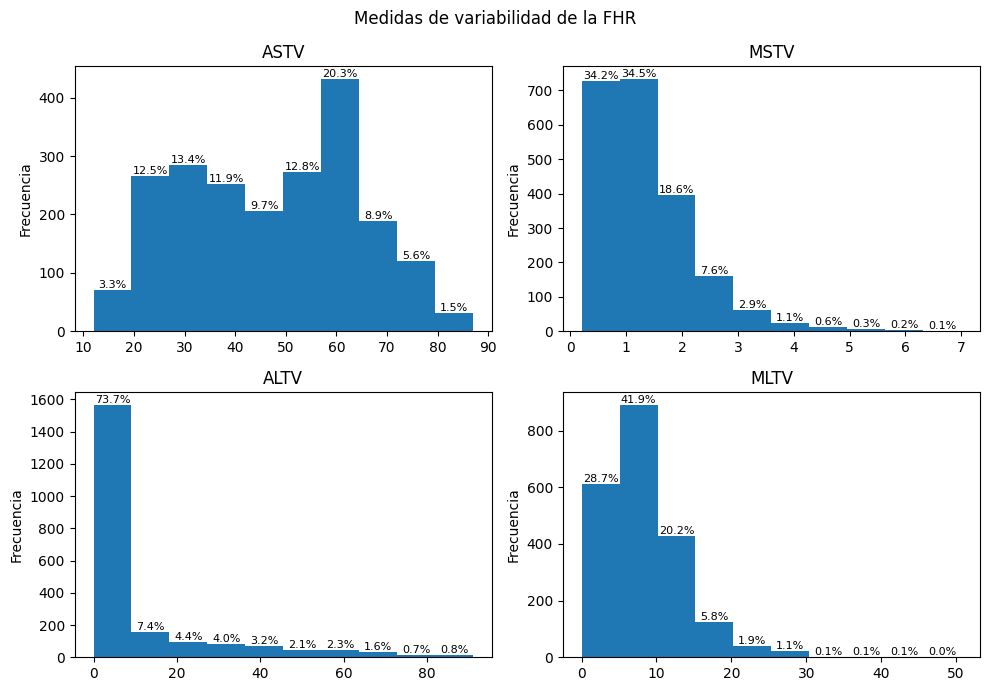

In [98]:
bins = 10

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for ax, col in zip(axes, lst_num_6):
    data = df_data[col].dropna()

    counts, bins_edges, patches = ax.hist(data, bins=bins)

    total = len(data)

    # Porcentajes sobre cada barra
    for count, patch in zip(counts, patches):
        if count > 0:
            percentage = count / total * 100
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                count,
                f'{percentage:.1f}%',
                ha='center',
                va='bottom',
                fontsize=8
            )

    ax.set_title(col)
    ax.set_ylabel('Frecuencia')

plt.gcf().suptitle('Medidas de variabilidad de la FHR', fontsize=12)
plt.tight_layout()
plt.show()


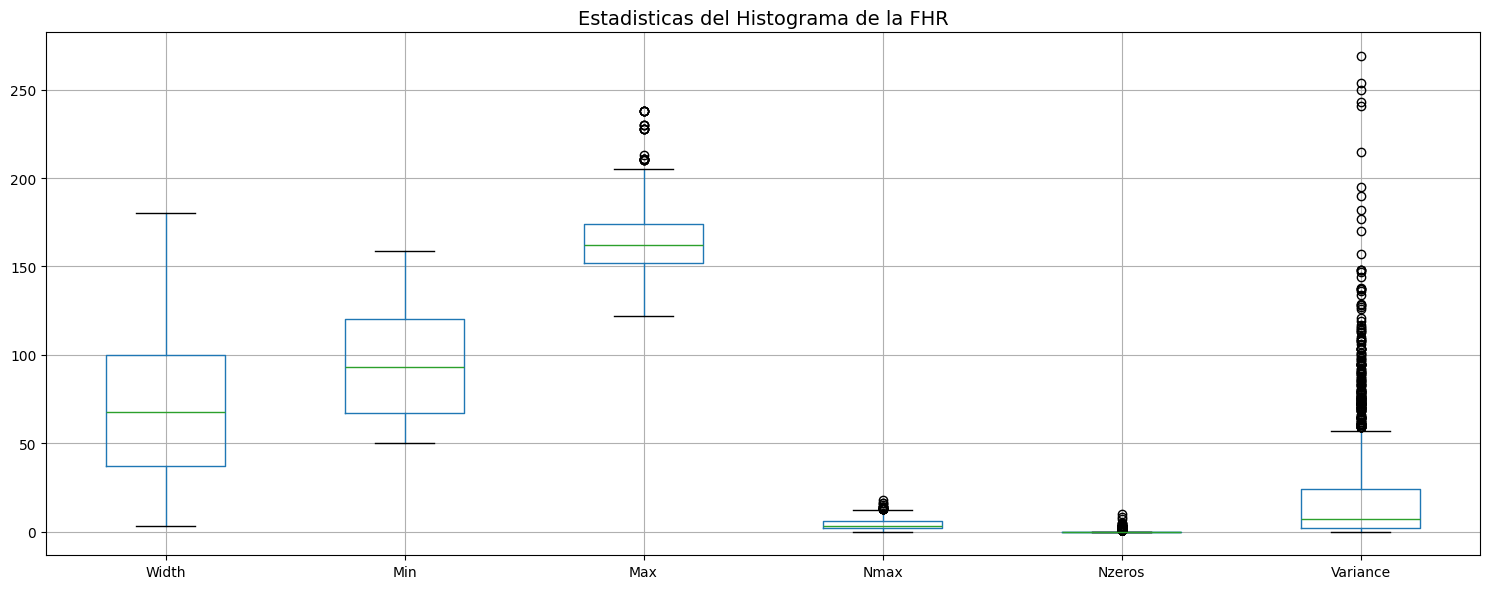

In [99]:
lst_num_7 = ['Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Variance']

# Se grafican los diagramas de caja de cada una de las variables numéricas

boxplot = df_data[lst_num_7].boxplot(figsize=(15,6))
plt.title('Estadisticas del Histograma de la FHR', fontsize=14)
plt.tight_layout()
plt.show()

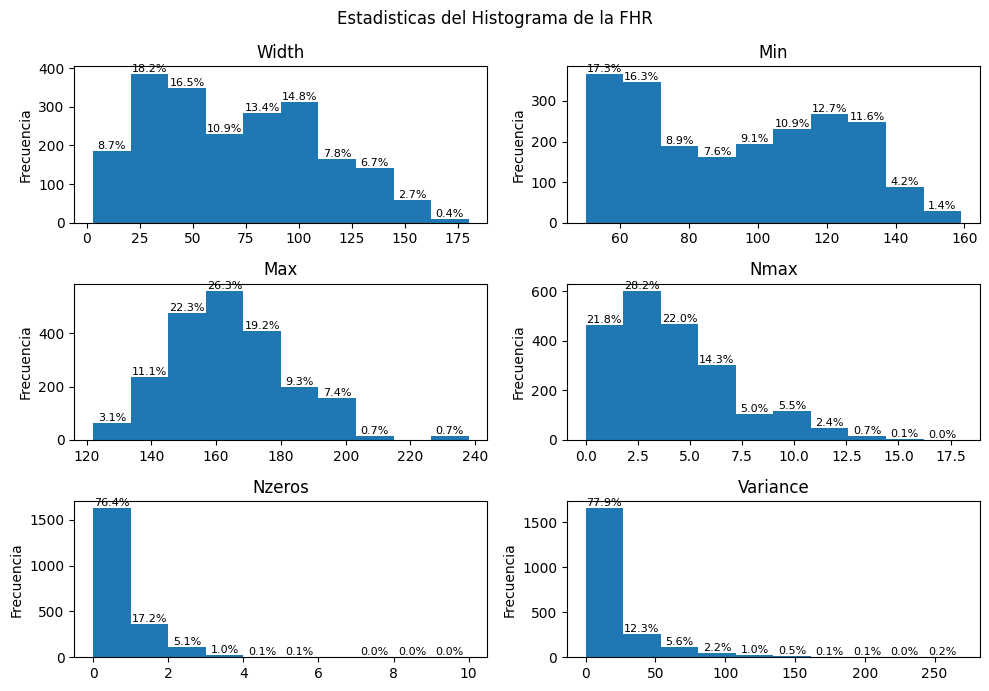

In [100]:
bins = 10

fig, axes = plt.subplots(3, 2, figsize=(10, 7))
axes = axes.flatten()

for ax, col in zip(axes, lst_num_7):
    data = df_data[col].dropna()

    counts, bins_edges, patches = ax.hist(data, bins=bins)

    total = len(data)

    # Porcentajes sobre cada barra
    for count, patch in zip(counts, patches):
        if count > 0:
            percentage = count / total * 100
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                count,
                f'{percentage:.1f}%',
                ha='center',
                va='bottom',
                fontsize=8
            )

    ax.set_title(col)
    ax.set_ylabel('Frecuencia')

plt.gcf().suptitle('Estadisticas del Histograma de la FHR', fontsize=12)
plt.tight_layout()
plt.show()


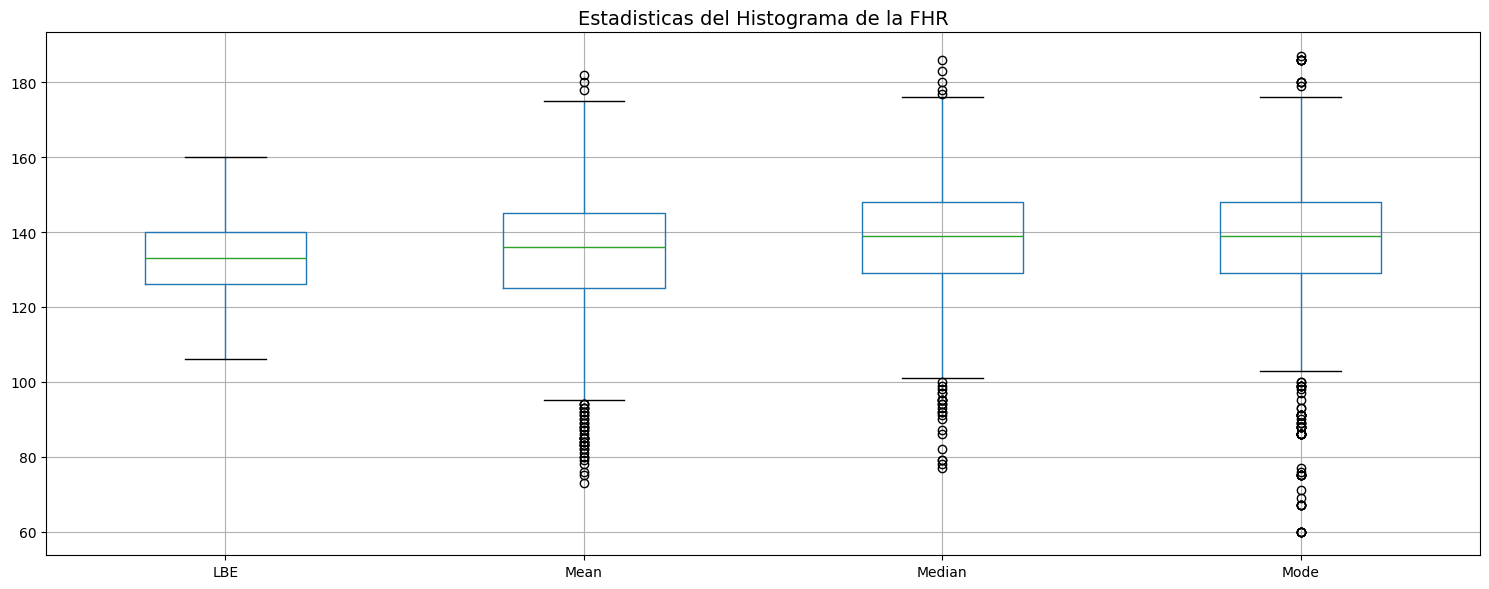

In [101]:
lst_num_8 = ['LBE', 'Mean', 'Median', 'Mode']

# Se grafican los diagramas de caja de cada una de las variables numéricas

boxplot = df_data[lst_num_8].boxplot(figsize=(15,6))
plt.title('Estadisticas del Histograma de la FHR', fontsize=14)
plt.tight_layout()
plt.show()

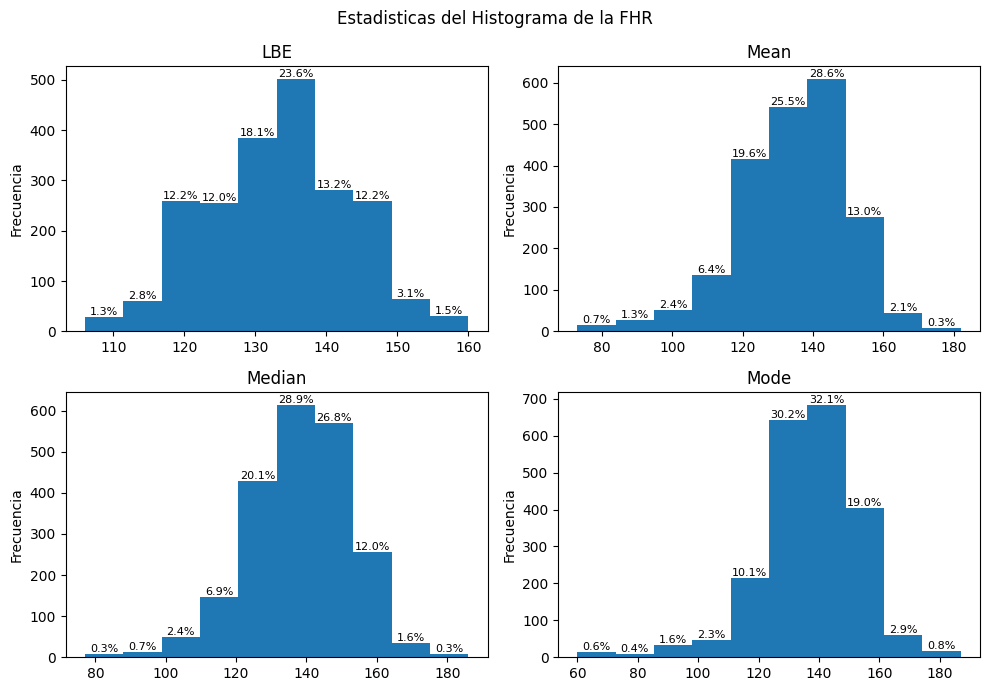

In [102]:
bins = 10

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for ax, col in zip(axes, lst_num_8):
    data = df_data[col].dropna()

    counts, bins_edges, patches = ax.hist(data, bins=bins)

    total = len(data)

    # Porcentajes sobre cada barra
    for count, patch in zip(counts, patches):
        if count > 0:
            percentage = count / total * 100
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                count,
                f'{percentage:.1f}%',
                ha='center',
                va='bottom',
                fontsize=8
            )

    ax.set_title(col)
    ax.set_ylabel('Frecuencia')

plt.gcf().suptitle('Estadisticas del Histograma de la FHR', fontsize=12)
plt.tight_layout()
plt.show()


<h3> Eliminación de datos </h3>

In [103]:
# Se realiza una copia del dataset para modificaciones
df_NSP = df_data.copy()

In [104]:
# Se eliminan las variables target relacionadas con la variable CLASS.

df_NSP.drop(['CLASS', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP'], axis=1, inplace=True)

In [105]:
# Inicializar el codificador
le = LabelEncoder()

# Transformar la columna 'Tendency' de variable categórica a variable numérica discreta
df_NSP['Tendency'] = le.fit_transform(df_NSP['Tendency'])

In [106]:
df_NSP.sample(10)

,LBE,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,...,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
1080,134.0,1.0,0.0,2.0,14.0,3.0,0.0,0.0,3.0,0.0,...,82.0,180.0,3.0,0.0,126.0,129.0,129.0,46.0,1,1.0
782,128.0,0.0,4.0,0.0,74.0,0.2,45.0,6.9,0.0,0.0,...,122.0,144.0,1.0,0.0,133.0,130.0,132.0,1.0,1,2.0
1827,140.0,0.0,1.0,2.0,61.0,1.3,0.0,3.9,7.0,0.0,...,66.0,159.0,7.0,1.0,142.0,135.0,144.0,24.0,2,1.0
369,138.0,0.0,9.0,1.0,64.0,0.4,30.0,7.0,2.0,0.0,...,118.0,159.0,2.0,0.0,144.0,143.0,145.0,5.0,1,2.0
401,150.0,0.0,0.0,0.0,47.0,1.1,15.0,7.1,1.0,0.0,...,61.0,197.0,5.0,0.0,159.0,154.0,157.0,8.0,2,1.0
847,138.0,1.0,0.0,4.0,40.0,0.8,7.0,10.8,0.0,0.0,...,105.0,154.0,5.0,0.0,142.0,141.0,143.0,1.0,2,1.0
201,120.0,0.0,10.0,0.0,56.0,0.5,12.0,8.5,0.0,0.0,...,103.0,133.0,2.0,0.0,120.0,121.0,122.0,1.0,1,1.0
476,145.0,0.0,0.0,1.0,62.0,0.5,8.0,10.1,1.0,0.0,...,70.0,157.0,1.0,1.0,148.0,145.0,148.0,4.0,2,2.0
792,146.0,1.0,0.0,17.0,55.0,0.7,32.0,8.2,5.0,0.0,...,93.0,165.0,4.0,0.0,150.0,147.0,150.0,6.0,2,1.0
2066,130.0,7.0,2.0,6.0,65.0,1.7,0.0,1.3,0.0,0.0,...,112.0,157.0,4.0,0.0,136.0,135.0,138.0,3.0,1,1.0


# 2. AGRUPAMIENTO POR CLUSTERS

In [107]:
'''Columnas como DS (99.6% de ceros) y DP (91.6% de ceros) harán que el algoritmo agrupe a casi todos los pacientes en un solo cluster gigante (el de los "normales"). Solo unos pocos registros tendrán un valor distinto de cero, lo que podría forzar la creación de micro-clusters'''

'Columnas como DS (99.6% de ceros) y DP (91.6% de ceros) harán que el algoritmo agrupe a casi todos los pacientes en un solo cluster gigante (el de los "normales"). Solo unos pocos registros tendrán un valor distinto de cero, lo que podría forzar la creación de micro-clusters'

<h3> Preprocesamiento de datos </h3>

<h3> Eliminación de datos </h3>

In [108]:
# Se realiza una copia del dataset para modificaciones
df_cluster = df_NSP.copy()

In [109]:
'''Las variables Mean, Median y Mode tienen una correlación superior al 90%. En clustering (especialmente K-Means), esto hace que el factor "promedio de latidos" cuente el triple que otros factores. Recomendación: Eliminar Mean y Mode, la variable Median es más robusta frente a valores extremos (outliers).'''

'Las variables Mean, Median y Mode tienen una correlación superior al 90%. En clustering (especialmente K-Means), esto hace que el factor "promedio de latidos" cuente el triple que otros factores. Recomendación: Eliminar Mean y Mode, la variable Median es más robusta frente a valores extremos (outliers).'

In [110]:
'''Tendency, al ser una variable con solo 3 valores posibles (-1, 0, 1), si no se normaliza correctamente, el algoritmo de clusters podría darle demasiada importancia a estos saltos discretos frente a variables continuas como la Variabilidad.'''

'Tendency, al ser una variable con solo 3 valores posibles (-1, 0, 1), si no se normaliza correctamente, el algoritmo de clusters podría darle demasiada importancia a estos saltos discretos frente a variables continuas como la Variabilidad.'

In [111]:
# Se eliminan las variables no necesarias para el análisis de anomalias y clusters.
df_cluster.drop(['Tendency', 'Mean', 'Mode'], axis=1, inplace=True)

In [112]:
df_cluster.sample(10)

,LBE,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,DP,Width,Min,Max,Nmax,Nzeros,Median,Variance,NSP
894,144.0,0.0,0.0,6.0,36.0,0.8,2.0,10.4,0.0,0.0,0.0,27.0,134.0,161.0,0.0,0.0,148.0,1.0,1.0
1137,122.0,0.0,0.0,3.0,30.0,1.1,0.0,7.6,2.0,0.0,0.0,39.0,93.0,132.0,2.0,0.0,125.0,4.0,1.0
1856,138.0,13.0,0.0,4.0,51.0,1.1,0.0,2.1,0.0,0.0,0.0,49.0,122.0,171.0,3.0,0.0,149.0,6.0,1.0
1072,133.0,0.0,0.0,4.0,31.0,1.4,16.0,13.0,2.0,0.0,0.0,82.0,82.0,164.0,5.0,0.0,140.0,31.0,1.0
1320,128.0,5.0,6.0,4.0,19.0,2.4,0.0,1.9,4.0,0.0,1.0,107.0,67.0,174.0,7.0,0.0,129.0,57.0,1.0
1257,118.0,0.0,0.0,5.0,26.0,1.2,0.0,11.1,0.0,0.0,0.0,44.0,100.0,144.0,3.0,0.0,120.0,2.0,1.0
59,144.0,5.0,0.0,4.0,33.0,1.1,0.0,6.2,0.0,0.0,0.0,100.0,78.0,178.0,5.0,0.0,152.0,8.0,1.0
1015,139.0,6.0,0.0,4.0,38.0,0.9,0.0,7.1,0.0,0.0,0.0,34.0,136.0,170.0,1.0,0.0,146.0,4.0,1.0
1723,134.0,5.0,1.0,6.0,53.0,1.8,0.0,0.9,4.0,0.0,0.0,83.0,83.0,166.0,5.0,0.0,140.0,29.0,1.0
1171,126.0,0.0,0.0,4.0,34.0,1.0,4.0,8.3,0.0,0.0,0.0,24.0,118.0,142.0,2.0,0.0,134.0,2.0,1.0


<h3> Dividir el dataset </h3>

<h3> Reescalar todos los atributos del dataset utilizando la función del RobustScaler </h3>

# 3. DETECCION DE ANOMALÍAS


Seleccionar/transformar características
Si hay categóricas: pd.get_dummies(df, drop_first=True) o aplicar encoders según convenga.

In [113]:
# Copia de trabajo
df = df_NSP.copy()

X = df.select_dtypes(include=[np.number]).copy()   # usa solo numéricas por simplicidad
X = X.fillna(X.median())                            # imputación simple
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

Crear datos sintéticos rompiendo dependencia entre columnas (permute cada columna)

In [114]:
X_synth = X_scaled.apply(np.random.permutation).reset_index(drop=True)

Construir dataset para entrenamiento (reales=1, sintéticos=0)

In [115]:
X_train = pd.concat([X_scaled, X_synth], ignore_index=True)
y_train = np.hstack([np.ones(len(X_scaled)), np.zeros(len(X_synth))])

Entrenar Random Forest

In [116]:
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Calcular score de anomalía para las muestras reales

In [117]:
proba_real = clf.predict_proba(X_scaled)[:, 1]   # prob de clase "real"
anomaly_score = 1.0 - proba_real                # mayor = más anómalo

Agregar a df original y marcar anomalías por cuantil o umbral

In [118]:
df_results = df.copy()
df_results['anomaly_score'] = anomaly_score
threshold = df_results['anomaly_score'].quantile(0.95)   # por ejemplo top 5% como anomalía
df_results['is_anomaly'] = df_results['anomaly_score'] > threshold

Inspeccionar resultados

In [119]:
print("Threshold (95q):", threshold)
print(df_results['is_anomaly'].sum(), "anomalías detectadas")
display(df_results.sort_values('anomaly_score', ascending=False).head(20))

Threshold (95q): 0.135
96 anomalías detectadas


,LBE,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,...,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP,anomaly_score,is_anomaly
383,131.0,4.0,20.0,0.0,44.0,0.8,0.0,4.6,0.0,0.0,...,1.0,0.0,137.0,146.0,140.0,38.0,0,1.0,0.300,True
0,120.0,0.0,0.0,0.0,73.0,0.5,43.0,2.4,0.0,0.0,...,2.0,0.0,120.0,137.0,121.0,73.0,2,2.0,0.260,True
1389,121.0,3.0,0.0,4.0,41.0,0.8,0.0,6.6,0.0,0.0,...,3.0,0.0,150.0,135.0,137.0,32.0,2,1.0,0.260,True
265,128.0,0.0,0.0,7.0,30.0,1.2,0.0,14.2,0.0,0.0,...,3.0,0.0,148.0,154.0,155.0,13.0,1,2.0,0.255,True
1927,140.0,0.0,5.0,4.0,62.0,2.4,2.0,0.3,1.0,0.0,...,3.0,0.0,131.0,123.0,130.0,11.0,2,3.0,0.255,True
705,133.0,0.0,0.0,8.0,60.0,0.7,58.0,9.9,0.0,0.0,...,8.0,1.0,133.0,132.0,134.0,2.0,1,2.0,0.250,True
121,123.0,0.0,0.0,3.0,50.0,0.8,32.0,3.1,3.0,0.0,...,7.0,0.0,125.0,122.0,126.0,8.0,1,1.0,0.250,True
1597,138.0,0.0,0.0,1.0,31.0,3.8,0.0,6.6,1.0,0.0,...,5.0,1.0,138.0,137.0,139.0,3.0,2,1.0,0.245,True
1609,144.0,0.0,29.0,1.0,65.0,3.3,0.0,2.7,5.0,0.0,...,3.0,0.0,147.0,109.0,149.0,17.0,2,1.0,0.240,True
1596,138.0,6.0,0.0,3.0,33.0,3.1,0.0,7.9,4.0,0.0,...,3.0,0.0,136.0,145.0,146.0,22.0,1,1.0,0.240,True


Visualización simple (histograma de scores)

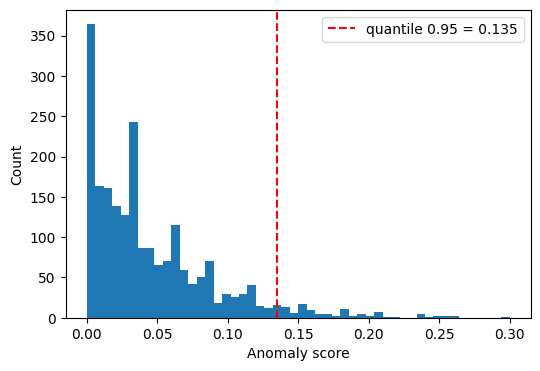

In [120]:
plt.figure(figsize=(6,4))
plt.hist(df_results['anomaly_score'], bins=50)
plt.axvline(threshold, color='r', linestyle='--', label=f'quantile 0.95 = {threshold:.3f}')
plt.xlabel('Anomaly score')
plt.ylabel('Count')
plt.legend()
plt.show()

In [112]:
# Se realiza una copia del dataset para modificaciones
df_anomalia = df_NSP.copy()

<h3> Dividir el dataset </h3>

<h3> Reescalar todos los atributos del dataset utilizando la función del RobustScaler </h3>

# 4. RESULTADOS